In [18]:
params = {
    "Pclass": 2,
    "Sex": "female",
    "Age": 30,
    "Fare": 20.0,
    "SibSp": 0,
    "Parch": 0,
    "Embarked": "S",
}

In [19]:
import json
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
ConfusionMatrixDisplay,
PrecisionRecallDisplay,
RocCurveDisplay,
accuracy_score,
average_precision_score,
classification_report,
confusion_matrix,
mean_absolute_error,
mean_squared_error,
precision_score,
r2_score,
recall_score,
roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)

In [20]:
def make_preprocess(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])

In [21]:
insurance = pd.read_csv(DATA / "medical_cost_personal_dataset.csv")
print(insurance.head())
X = insurance.drop(columns="charges")
y = insurance["charges"]
num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [22]:
fitted = {}
predictions = {}
for name, estimator in {
    "linear regression": LinearRegression(),
    "ridge": Ridge(alpha=10.0),
    }.items():
    model = Pipeline([("preprocess", make_preprocess(num_cols, cat_cols)), ("model", estimator)])
    model.fit(X_train, y_train)
    fitted[name] = model
    predictions[name] = model.predict(X_valid)
    pred = predictions[name]
    print(f"\n{name}")
    print("MAE:", round(mean_absolute_error(y_valid, pred), 2))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_valid, pred)), 2))
    print("R2:", round(r2_score(y_valid, pred), 3))


linear regression
MAE: 4181.19
RMSE: 5796.28
R2: 0.784

ridge
MAE: 4238.82
RMSE: 5821.59
R2: 0.782


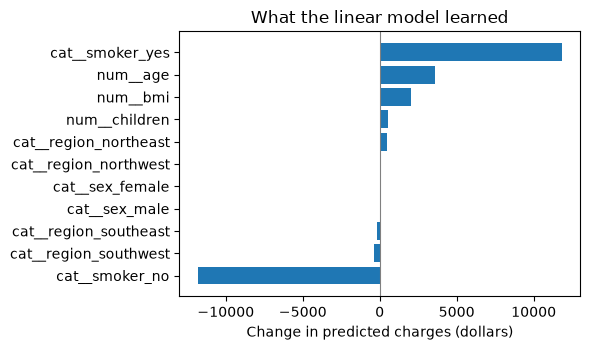

In [23]:
linear = fitted["linear regression"]
names = linear.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(linear.named_steps["model"].coef_, index=names).sort_values()
plt.figure(figsize=(6, 3.6))
plt.barh(coefs.index, coefs.values)
plt.axvline(0, color="grey", linewidth=0.8)
plt.xlabel("Change in predicted charges (dollars)")
plt.title("What the linear model learned")
plt.tight_layout()
plt.show()

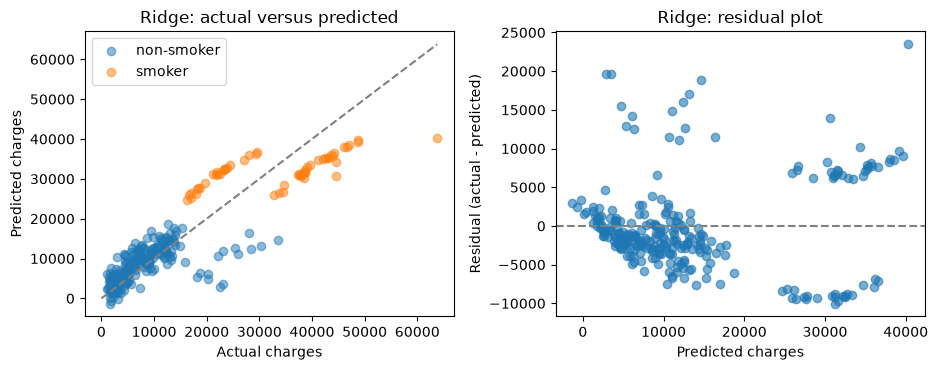

In [24]:
ridge_pred = predictions["ridge"]
residual = y_valid.to_numpy() - ridge_pred
is_smoker = (X_valid["smoker"] == "yes").to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
axes[0].scatter(y_valid[~is_smoker], ridge_pred[~is_smoker], alpha=0.5, label="non-smoker")
axes[0].scatter(y_valid[is_smoker], ridge_pred[is_smoker], alpha=0.5, label="smoker")
axes[0].plot([0, y_valid.max()], [0, y_valid.max()], linestyle="--", color="grey")
axes[0].set_xlabel("Actual charges")
axes[0].set_ylabel("Predicted charges")
axes[0].set_title("Ridge: actual versus predicted")
axes[0].legend()
axes[1].scatter(ridge_pred, residual, alpha=0.6)
axes[1].axhline(0, linestyle="--", color="grey")
axes[1].set_xlabel("Predicted charges")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Ridge: residual plot")
plt.tight_layout()
plt.show()

In [25]:
bikes = pd.read_csv(DATA / "bike_sharing_dataset_day.csv")
bikes["dteday"] = pd.to_datetime(bikes["dteday"])
bikes = bikes.sort_values("dteday").reset_index(drop=True)
# cnt = casual + registered, so those two columns would leak the answer.
bike_cat = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
bike_num = ["temp", "atemp", "hum", "windspeed"]
X_b = bikes[bike_cat + bike_num]
y_b = bikes["cnt"]
cut = int(len(bikes) * 0.80)
print("train:", bikes["dteday"].iloc[0].date(), "to", bikes["dteday"].iloc[cut - 1].date())
print("valid:", bikes["dteday"].iloc[cut].date(), "to", bikes["dteday"].iloc[-1].date())

train: 2011-01-01 to 2012-08-06
valid: 2012-08-07 to 2012-12-31


daily MAE: 1040.4  (mean daily demand in validation: 5897.8 )


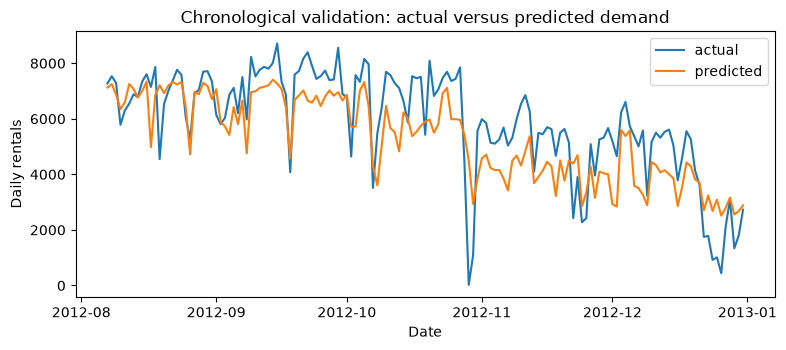

In [26]:
Xb_train, Xb_valid = X_b.iloc[:cut], X_b.iloc[cut:]
yb_train, yb_valid = y_b.iloc[:cut], y_b.iloc[cut:]
dates_valid = bikes["dteday"].iloc[cut:]
bike_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), bike_cat),
        ("num", "passthrough", bike_num),
    ])),
    ("model", RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1
    )),
])
bike_model.fit(Xb_train, yb_train)
bike_pred = bike_model.predict(Xb_valid)
print("daily MAE:", round(mean_absolute_error(yb_valid, bike_pred), 1),
" (mean daily demand in validation:", round(yb_valid.mean(), 1), ")")
plt.figure(figsize=(8, 3.6))
plt.plot(dates_valid, yb_valid.to_numpy(), label="actual")
plt.plot(dates_valid, bike_pred, label="predicted")
plt.xlabel("Date")
plt.ylabel("Daily rentals")
plt.title("Chronological validation: actual versus predicted demand")
plt.legend()
plt.tight_layout()
plt.show()

hourly MAE: 56.5  (mean hourly demand in validation: 248.8 )


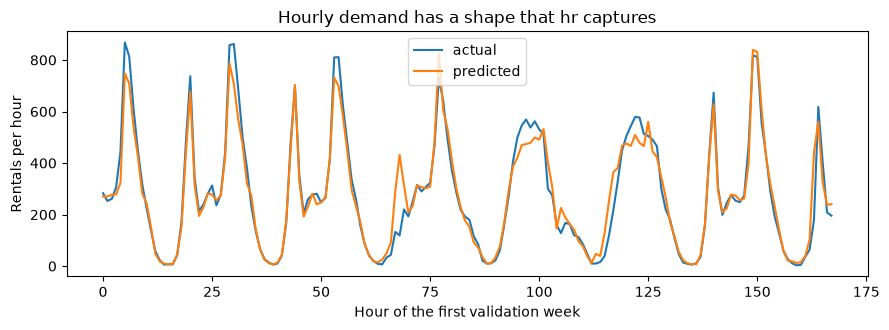

In [27]:
hourly = pd.read_csv(DATA / "bike_sharing_dataset_hour.csv")
hourly["dteday"] = pd.to_datetime(hourly["dteday"])
hourly = hourly.sort_values(["dteday", "hr"]).reset_index(drop=True)
hour_cat = bike_cat + ["hr"]
Xh = hourly[hour_cat + bike_num]
yh = hourly["cnt"]
cut_h = int(len(hourly) * 0.80)
hour_model = Pipeline([
("preprocess", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), hour_cat),
        ("num", "passthrough", bike_num),
    ])),
    ("model", RandomForestRegressor(
        n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1
    )),
])
hour_model.fit(Xh.iloc[:cut_h], yh.iloc[:cut_h])
hour_pred = hour_model.predict(Xh.iloc[cut_h:])
print("hourly MAE:", round(mean_absolute_error(yh.iloc[cut_h:], hour_pred), 1),
" (mean hourly demand in validation:", round(yh.iloc[cut_h:].mean(), 1), ")")
week = slice(0, 24 * 7)
plt.figure(figsize=(9, 3.4))
plt.plot(range(24 * 7), yh.iloc[cut_h:].to_numpy()[week], label="actual")
plt.plot(range(24 * 7), hour_pred[week], label="predicted")
plt.xlabel("Hour of the first validation week")
plt.ylabel("Rentals per hour")
plt.title("Hourly demand has a shape that hr captures")
plt.legend()
plt.tight_layout()
plt.show()

majority-class baseline accuracy: 0.614
logistic       accuracy=0.776 roc_auc=0.842
random_forest  accuracy=0.798 roc_auc=0.834
threshold 0.30: precision=0.64 recall=0.81
threshold 0.50: precision=0.72 recall=0.67
threshold 0.70: precision=0.90 recall=0.50


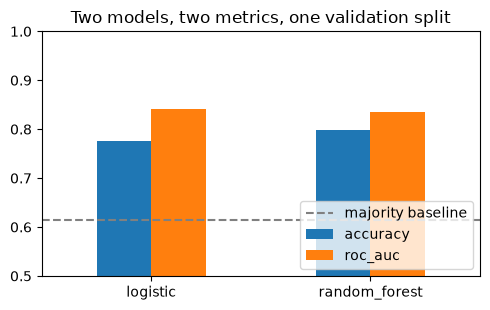

In [28]:
titanic = pd.read_csv(DATA / "titanic_dataset.csv")
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
t_num = ["Age", "SibSp", "Parch", "Fare"]
t_cat = ["Pclass", "Sex", "Embarked"]
X_t = titanic[features]
y_t = titanic["Survived"]
Xt_train, Xt_valid, yt_train, yt_valid = train_test_split(
X_t, y_t, test_size=0.25, random_state=42, stratify=y_t
)
print("majority-class baseline accuracy:", round(1 - yt_valid.mean(), 3))
scores = {}
fitted_t = {}
for name, estimator in {
    "logistic": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
random_state=42),
}.items():
    pipe = Pipeline([("preprocess", make_preprocess(t_num, t_cat)), ("model", estimator)])
    pipe.fit(Xt_train, yt_train)
    fitted_t[name] = pipe
    scores[name] = {"accuracy": accuracy_score(yt_valid, pipe.predict(Xt_valid)), "roc_auc": roc_auc_score(yt_valid, pipe.predict_proba(Xt_valid)[:, 1])}
    print(f"{name:14s} accuracy={scores[name]['accuracy']:.3f} "
        f"roc_auc={scores[name]['roc_auc']:.3f}")
    
# The same logistic model, three decision rules (the table in the notes).
prob_t = fitted_t["logistic"].predict_proba(Xt_valid)[:, 1]
for threshold in [0.30, 0.50, 0.70]:
    pred_t = (prob_t >= threshold).astype(int)
    print(f"threshold {threshold:.2f}: precision={precision_score(yt_valid, pred_t):.2f} " 
          f"recall={recall_score(yt_valid, pred_t):.2f}")
pd.DataFrame(scores).T.plot.bar(figsize=(5, 3.2), ylim=(0.5, 1.0), rot=0)
plt.axhline(1 - yt_valid.mean(), linestyle="--", color="grey", label="majority baseline")
plt.title("Two models, two metrics, one validation split")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

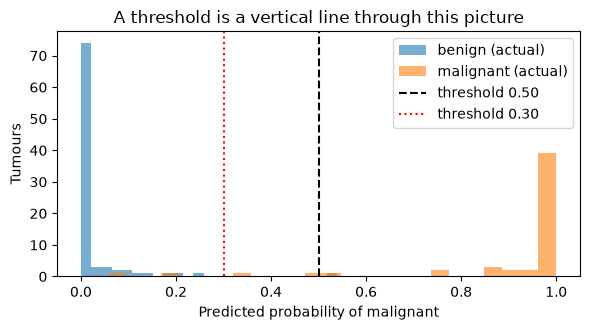

In [29]:
cancer = pd.read_csv(DATA / "breast_cancer_dataset.csv")
X_c = cancer.drop(columns=["id", "diagnosis", "Unnamed: 32"], errors="ignore")
y_c = (cancer["diagnosis"] == "M").astype(int)
Xc_train, Xc_valid, yc_train, yc_valid = train_test_split(
X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
)
cancer_model = Pipeline([
("scale", StandardScaler()),
("model", LogisticRegression(max_iter=2000)),
])
cancer_model.fit(Xc_train, yc_train)
prob = cancer_model.predict_proba(Xc_valid)[:, 1]
plt.figure(figsize=(6, 3.4))
plt.hist(prob[yc_valid == 0], bins=25, alpha=0.6, label="benign (actual)")
plt.hist(prob[yc_valid == 1], bins=25, alpha=0.6, label="malignant (actual)")
plt.axvline(0.50, color="black", linestyle="--", label="threshold 0.50")
plt.axvline(0.30, color="red", linestyle=":", label="threshold 0.30")
plt.xlabel("Predicted probability of malignant")
plt.ylabel("Tumours")
plt.title("A threshold is a vertical line through this picture")
plt.legend()
plt.tight_layout()
plt.show()




threshold = 0.50
[[89  1]
 [ 4 49]]
              precision    recall  f1-score   support

           0      0.957     0.989     0.973        90
           1      0.980     0.925     0.951        53

    accuracy                          0.965       143
   macro avg      0.968     0.957     0.962       143
weighted avg      0.966     0.965     0.965       143



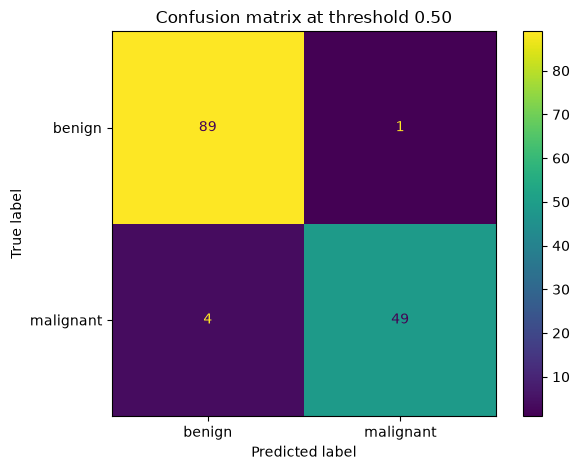


threshold = 0.30
[[89  1]
 [ 2 51]]
              precision    recall  f1-score   support

           0      0.978     0.989     0.983        90
           1      0.981     0.962     0.971        53

    accuracy                          0.979       143
   macro avg      0.979     0.976     0.977       143
weighted avg      0.979     0.979     0.979       143



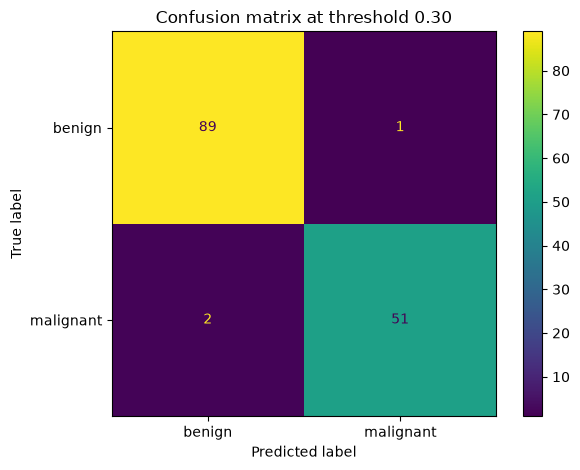

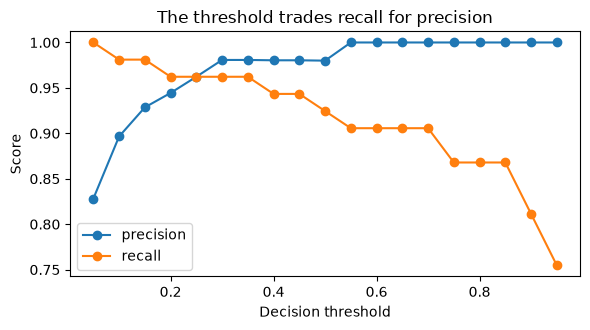

In [30]:
for threshold in [0.50, 0.30]:
    pred = (prob >= threshold).astype(int)
    print(f"\nthreshold = {threshold:.2f}")
    print(confusion_matrix(yc_valid, pred))
    print(classification_report(yc_valid, pred, digits=3))
    ConfusionMatrixDisplay.from_predictions(yc_valid, pred, display_labels=["benign", "malignant"])
    plt.title(f"Confusion matrix at threshold {threshold:.2f}")
    plt.tight_layout()
    plt.show()
thresholds = np.linspace(0.05, 0.95, 19)
precisions = [precision_score(yc_valid, (prob >= t).astype(int), zero_division=0) for t in thresholds]
recalls = [recall_score(yc_valid, (prob >= t).astype(int)) for t in thresholds]
plt.figure(figsize=(6, 3.4))
plt.plot(thresholds, precisions, marker="o", label="precision")
plt.plot(thresholds, recalls, marker="o", label="recall")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("The threshold trades recall for precision")
plt.legend()
plt.tight_layout()
plt.show()

ROC AUC: 0.996
PR AUC: 0.994


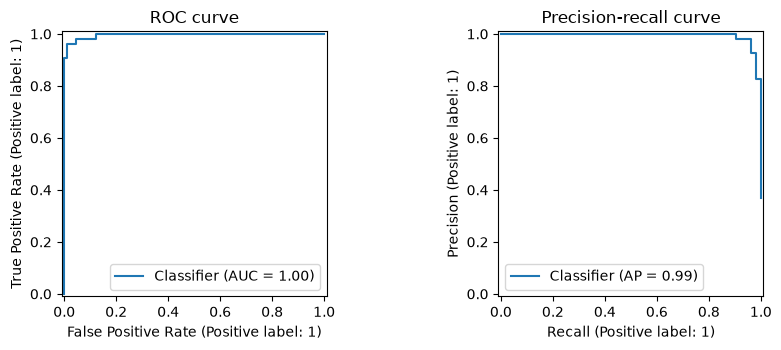

In [31]:
print("ROC AUC:", round(roc_auc_score(yc_valid, prob), 3))
print("PR AUC:", round(average_precision_score(yc_valid, prob), 3))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
RocCurveDisplay.from_predictions(yc_valid, prob, ax=axes[0])
axes[0].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(yc_valid, prob, ax=axes[1])
axes[1].set_title("Precision-recall curve")
plt.tight_layout()
plt.show()

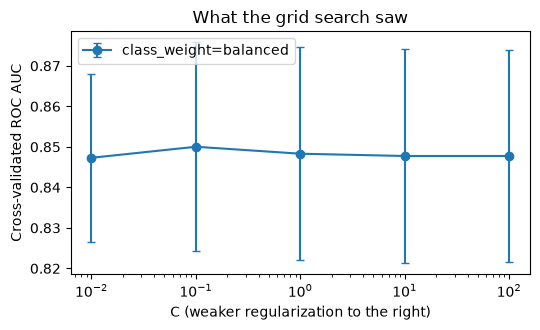

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
X_t, y_t, test_size=0.25, random_state=42, stratify=y_t
)
search = GridSearchCV(
Pipeline([("preprocess", make_preprocess(t_num, t_cat)),
("model", LogisticRegression(max_iter=2000))]),
param_grid={
"model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
"model__class_weight": [None, "balanced"],
},
scoring="roc_auc",
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
n_jobs=-1,
)
search.fit(X_train, y_train)
cv_table = pd.DataFrame(search.cv_results_)
plt.figure(figsize=(5.5, 3.4))
for weight, group in cv_table.groupby(cv_table["param_model__class_weight"].astype(str)):
    plt.errorbar(group["param_model__C"].astype(float), group["mean_test_score"],
            yerr=group["std_test_score"], marker="o", capsize=3, label=f"class_weight={weight}")
plt.xscale("log")
plt.xlabel("C (weaker regularization to the right)")
plt.ylabel("Cross-validated ROC AUC")
plt.title("What the grid search saw")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
test_prob = search.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_prob)
print("best parameters:", search.best_params_)
print("cross-validated ROC AUC:", round(search.best_score_, 3))
print("final test ROC AUC:", round(test_auc, 3))

best parameters: {'model__C': 0.1, 'model__class_weight': 'balanced'}
cross-validated ROC AUC: 0.85
final test ROC AUC: 0.837


In [34]:
final_model = search.best_estimator_
model_path = MODELS / "titanic_survival.joblib"
joblib.dump(final_model, model_path)
card = {
"task": "predict Titanic survival (1 = survived)",
"features": features,
"model": "logistic regression pipeline",
"best_parameters": search.best_params_,
"training_rows": int(len(X_train)),
"final_test_roc_auc": round(float(test_auc), 3),
"decision_threshold": 0.5,
"scikit_learn_version": sklearn.__version__,
}
(MODELS / "titanic_survival_card.json").write_text(json.dumps(card, indent=2))
size_kb = model_path.stat().st_size / 1024
print(f"saved: {model_path.name} ({size_kb:.1f} KB) and titanic_survival_card.json")

saved: titanic_survival.joblib (4.5 KB) and titanic_survival_card.json


In [35]:
loaded = joblib.load(model_path)
new_passengers = pd.DataFrame([
{"Pclass": 1, "Sex": "female", "Age": 29, "SibSp": 0, "Parch": 0, "Fare": 80.0, "Embarked": "C"},
{"Pclass": 3, "Sex": "male", "Age": 40, "SibSp": 0, "Parch": 0, "Fare": 7.9, "Embarked": "S"},
])
new_passengers["survival_probability"] = loaded.predict_proba(new_passengers)[:, 1].round(3)
print(new_passengers)
joblib.dump(fitted["linear regression"], MODELS / "insurance_charges.joblib")
pricing = joblib.load(MODELS / "insurance_charges.joblib")
new_customer = pd.DataFrame([
{"age": 35, "sex": "female", "bmi": 27.5, "children": 2, "smoker": "no", "region": "southeast"},
{"age": 35, "sex": "female", "bmi": 27.5, "children": 2, "smoker": "yes", "region": "southeast"},
])
new_customer["predicted_charges"] = pricing.predict(new_customer).round(0)
print(new_customer)

   Pclass     Sex  Age  SibSp  Parch  Fare Embarked  survival_probability
0       1  female   29      0      0  80.0        C                 0.942
1       3    male   40      0      0   7.9        S                 0.141
   age     sex   bmi  children smoker     region  predicted_charges
0   35  female  27.5         2     no  southeast             6526.0
1   35  female  27.5         2    yes  southeast            30177.0


In [36]:
test_passenger = pd.DataFrame([params])[features]
prob_survive = joblib.load(MODELS / "titanic_survival.joblib").predict_proba(test_passenger)[0, 1]
print(f"survival probability: {prob_survive:.3f} -> {'survived' if prob_survive >= 0.5 else 'did not survive'}")

survival probability: 0.805 -> survived
